# Day 1 — From a Model Call to an Agent

**Project of the day: a Smart Research Assistant.** By the last section you will have an
assistant that reads a question, decides whether it needs a calculator or the course notes,
uses them through code *you* control, and returns a validated, inspectable answer.

**How to use this notebook**

- Run the cells in order. Every cell prints something; read the output before moving on.
- Nothing needs installing except LangGraph in section 1.6. There is no repository to clone.
- Without an API key the notebook runs on a built-in *mock model*: the replies are canned,
  but the request and response **shapes** are exactly what a real model produces, so every
  mechanism can be learned and tested for free.
- Each section ends with a two-question checkpoint (answers fold out) and a three-line recap.

**Contents**

1. [Your first model call](#day-1-section-1)
2. [Configuring model behaviour](#day-1-section-2)
3. [Structured outputs](#day-1-section-3)
4. [Tool calling](#day-1-section-4)
5. [The agent loop — you build it](#day-1-section-5)
6. [The same loop in LangGraph (optional)](#day-1-section-6)
7. [Project: Smart Research Assistant](#day-1-section-7)

## Your API key (30 seconds)

The course model runs on OpenRouter. Give this notebook your issued key in one of two ways:

- **Recommended:** click the key icon in Colab's left sidebar, add a secret named
  `OPENROUTER_API_KEY`, and switch on *Notebook access*. Every course notebook then finds it automatically.
- **Or:** run the cell below and paste the key when asked (it is kept only in this session).

No key? Just press Enter when asked. The notebook switches to the mock model and everything still runs.
Never paste a key into a code cell: notebooks get shared.

In [ ]:
# === Setup: run this cell first ===============================================
# It reads your API key, creates the client, and defines chat(): the ONE function
# every section of this notebook uses to talk to the model.
import json, os, re
from getpass import getpass

MODEL = "openai/gpt-oss-120b"          # the course model on OpenRouter

def load_api_key():
    """Look for the key in Colab Secrets, then the environment, then ask once."""
    try:
        from google.colab import userdata           # only exists on Colab
        key = userdata.get("OPENROUTER_API_KEY")
        if key:
            return key, "Colab secret"
    except Exception:
        pass                                        # not on Colab, or no secret yet
    if os.getenv("OPENROUTER_API_KEY"):
        return os.environ["OPENROUTER_API_KEY"], "environment variable"
    try:
        key = getpass("OpenRouter API key (press Enter to use the mock model): ").strip()
    except Exception:                               # no keyboard available (automated run)
        key = ""
    return (key, "typed in") if key else ("", "none")

API_KEY, KEY_SOURCE = load_api_key()
LIVE = bool(API_KEY)                                # True = real model, False = mock model
client = None
if LIVE:
    from openai import OpenAI                       # the OpenAI SDK speaks OpenRouter's API too
    client = OpenAI(base_url="https://openrouter.ai/api/v1", api_key=API_KEY)

def chat(messages, tools=None, response_format=None, temperature=0.0, max_tokens=600):
    """Send ONE request to the model and return a plain dict:
         {"content": str, "tool_calls": [{"id", "name", "arguments"}], "usage": {...}}
    Everything else in this notebook is built on top of this function."""
    if not LIVE:
        return mock_model(messages, tools, response_format)
    request = dict(model=MODEL, messages=messages, temperature=temperature, max_tokens=max_tokens,
                   extra_body={"reasoning": {"effort": "low"}})   # keep hidden reasoning short and cheap
    if tools:
        request["tools"] = tools
    if response_format:
        request["response_format"] = response_format
    response = client.chat.completions.create(**request)
    message = response.choices[0].message
    calls = [{"id": call.id, "name": call.function.name,
              "arguments": json.loads(call.function.arguments or "{}")}
             for call in (message.tool_calls or [])]
    usage = response.usage
    return {"content": message.content or "", "tool_calls": calls,
            "usage": {"prompt_tokens": usage.prompt_tokens, "completion_tokens": usage.completion_tokens,
                      "total_tokens": usage.total_tokens}}

print("Model  :", MODEL)
print("Key    :", KEY_SOURCE)
print("Mode   :", "LIVE - real model replies" if LIVE else "MOCK - canned replies, real shapes, zero cost")

### The mock model (read later, or never)

When there is no key, `chat()` hands the request to the function below. It answers the
handful of questions used in this notebook with fixed rules. You do not need to understand
it now; it exists so that every mechanism you build today can run and be tested without spending credit.

In [ ]:
def _mock_reply(content="", calls=None):
    return {"content": content, "tool_calls": calls or [],
            "usage": {"prompt_tokens": 0, "completion_tokens": 0, "total_tokens": 0}}

def mock_model(messages, tools=None, response_format=None):
    """A stand-in model: fixed rules, real reply shapes. Understands only this notebook's questions."""
    user_text = next((m["content"] for m in reversed(messages) if m["role"] == "user"), "")
    lower = user_text.lower()
    system_text = " ".join(m["content"] for m in messages if m["role"] == "system").lower()
    tool_names = [t["function"]["name"] for t in (tools or [])]
    tools_already_used = {call["function"]["name"] for m in messages if m["role"] == "assistant"
                          for call in m.get("tool_calls", [])}
    tool_results = [m["content"] for m in messages if m["role"] == "tool"]

    # 1) Decide whether a tool is needed: notes first, then the calculator.
    if "search_local_notes" in tool_names and "search_local_notes" not in tools_already_used:
        topic = re.search(r"what is an? ([a-z ]+?)(?:[,?.]|$)", lower)
        if topic:
            return _mock_reply(calls=[{"id": "call_notes_1", "name": "search_local_notes",
                                       "arguments": {"query": topic.group(1).strip()}}])
    arithmetic = re.search(r"(\d[\d\s.]*[*+\-/x×][\d\s.*+\-/x×()]*\d)", lower)
    if "calculator" in tool_names and "calculator" not in tools_already_used and arithmetic:
        expression = arithmetic.group(1).replace("×", "*").replace("x", "*").replace(" ", "")
        return _mock_reply(calls=[{"id": "call_calc_1", "name": "calculator",
                                   "arguments": {"expression": expression}}])

    # 2) A JSON schema was requested: answer in that shape.
    if response_format:
        summary = " ".join(tool_results) if tool_results else f"A short mock answer about: {user_text}"
        answer = {"topic": user_text[:60], "summary": summary[:300], "key_points": [summary[:120]],
                  "tools_used": sorted(tools_already_used), "confidence": 0.8}
        return _mock_reply(json.dumps(answer))

    # 3) Plain-text answers for the questions in sections 1 and 2.
    if tool_results:
        return _mock_reply("Using the tool results: " + " | ".join(tool_results))
    if "my name" in lower:
        told = re.search(r"my name is (\w+)", " ".join(m["content"] for m in messages if m["role"] == "user"), re.I)
        return _mock_reply(f"Your name is {told.group(1)}." if told
                           else "I don't know your name - you have not told me in this conversation.")
    if "dictionary" in lower or "json" in lower:
        return _mock_reply("Sure! Here is the dictionary: {'task': 'write the lab report', 'due': 'Friday', "
                           "'priority': 'high'}. Let me know if you need anything else.")
    if "three" in system_text and "section" in system_text:
        return _mock_reply("Definition: recursion is a function calling itself on a smaller input.\n"
                           "Example: factorial(n) = n * factorial(n - 1), with factorial(0) = 1.\n"
                           "When to avoid: very deep inputs, because every call uses stack memory.")
    return _mock_reply("Recursion is when a function solves a problem by calling itself on a smaller version "
                       "of the same problem until it reaches a case simple enough to answer directly. It is "
                       "elegant for trees and nested data, but deep recursion can exhaust the call stack, so a "
                       "loop is sometimes the safer choice.")

print("mock model ready" + ("" if LIVE else " and active"))

<a id="day-1-section-1"></a>

## 1.1 — Your First Model Call

A language model is a text-in, text-out service. Your program sends a list of **messages**;
the model sends back one reply. It does not remember previous calls, cannot run code, and
cannot see your files. Everything that looks like memory or action is added by the program around it.

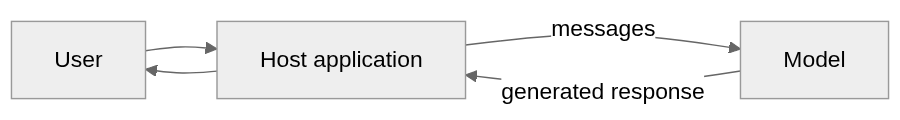

*D01 — the host application sends messages to the model and returns the reply*

### Step 1 — Send a message list, get a reply

A request is a list of dictionaries with a `role` and `content`. Two roles for now:
`system` (standing instructions) and `user` (the current task).

In [ ]:
messages = [
    {"role": "system", "content": "You are a concise tutor for engineering students."},
    {"role": "user", "content": "Explain recursion in three sentences."},
]
reply = chat(messages)

print("REPLY TEXT:\n", reply["content"])
print("\nUSAGE     :", reply["usage"])      # tokens in + tokens out = what you pay for

### Step 2 — The model forgets everything between calls

Send a fact in one call, ask about it in a *fresh* call. The model cannot answer, because the
second request never contained the fact. A conversation only "remembers" when the program
re-sends the earlier messages.

In [ ]:
first = chat([{"role": "user", "content": "My name is Aurora. Please remember it."}])
print("call 1 :", first["content"][:80])

# A brand-new message list: the earlier message is NOT included.
second = chat([{"role": "user", "content": "What is my name?"}])
print("call 2 :", second["content"])

# Re-send the history and the model can answer.
third = chat([
    {"role": "user", "content": "My name is Aurora. Please remember it."},
    {"role": "assistant", "content": first["content"]},
    {"role": "user", "content": "What is my name?"},
])
print("call 3 :", third["content"], "   <- only because WE re-sent the history")

### Step 3 — The context window and `max_tokens`

Everything in one request, plus the reply being generated, must fit in the model's **context
window** (a fixed token budget). `max_tokens` caps only the reply. Set it too low and the answer
is cut off mid-sentence; on reasoning models some of it is spent on hidden reasoning first.

In [ ]:
short = chat(messages, max_tokens=40)
print("with max_tokens=40 :", repr(short["content"][:160]))
print("\nThe mock ignores max_tokens; the live model truncates. Either way, the LIMIT belongs to your request, not to the model.")

### Live observation

If you are in LIVE mode, run Step 1 twice and compare the two replies: the wording differs
slightly even at `temperature=0`, but the usage record and the structure of the reply are the
same. That variability is why later sections validate outputs instead of trusting wording.

### Checkpoint

**1. The model answered a recursion question. Did any Python run inside the model, and where did the length limit come from?**

<details><summary>Show answer</summary>

No Python ran. The model only generated text. The limit came from `max_tokens` in the request *we* built.

</details>

**2. Why could call 2 not answer, but call 3 could?**

<details><summary>Show answer</summary>

Call 2 was a new request containing only the question. Call 3 contained the earlier messages again. The model has no memory; the program supplies continuity by re-sending history.

</details>

### Recap

- **Limitation seen:** one call is one text-in, text-out operation; nothing persists.
- **Layer added:** a message list built by our code, plus a `chat()` helper we control.
- **Evidence:** call 2 failed and call 3 succeeded, differing only in what we sent.

<a id="day-1-section-2"></a>

## 1.2 — Configuring Model Behaviour

Instructions and settings *steer* a probabilistic generator; they do not program it.
This section shows what a system message and `temperature` change, and then shows that an
instruction is not a contract.

### Step 1 — Same question, with and without standing instructions

The **system** message is the job description; the **user** message is today's task.
Compare the reply when we demand a fixed three-section format.

In [ ]:
question = {"role": "user", "content": "Explain recursion."}

free = chat([question])
constrained = chat([
    {"role": "system", "content": "Answer in exactly three sections labelled Definition, Example, When to avoid. One sentence each."},
    question,
])
print("WITHOUT system message:\n", free["content"][:300])
print("\nWITH system message:\n", constrained["content"])

### Step 2 — `temperature`

`temperature` controls how freely the model samples the next token. `0` takes the most likely
continuation every time (use it for tools, extraction, pipelines); higher values trade
repeatability for variety (brainstorming). It changes *how adventurous* the reply is, not *what the job is*.

In [ ]:
for temperature in (0.0, 1.0):
    reply = chat([{"role": "user", "content": "Give me one creative name for a study-group app."}], temperature=temperature)
    print(f"temperature={temperature}: {reply['content'][:90]}")
print("\nThe mock ignores temperature. Live, run this cell twice: temperature=0 repeats, temperature=1 varies.")

### Step 3 — Break it: an instruction is not a contract

Ask nicely for a dictionary. The reply *looks* right to a human and still cannot be parsed by
Python. This is the problem the next section solves.

In [ ]:
reply = chat([{"role": "user", "content": "Give me a dictionary with keys task, due and priority for 'write the lab report by Friday'."}])
print("REPLY:", reply["content"])
try:
    json.loads(reply["content"])
    print("Parsed as JSON - lucky this time; it is not guaranteed.")
except json.JSONDecodeError as error:
    print("\njson.loads FAILED:", error)
    print("Looks fine to a person, useless to a program.")

### Checkpoint

**1. A teammate says: 'I told it to always return JSON in the system prompt, so parsing is safe.' What is wrong?**

<details><summary>Show answer</summary>

A prompt raises the probability of JSON; it does not guarantee it. Only a schema-enforced request plus validation in code makes parsing safe. Section 1.3 does exactly that.

</details>

**2. When would you deliberately use `temperature=1`?**

<details><summary>Show answer</summary>

When variety is the goal and no code depends on the exact output: brainstorming names, drafting alternatives. Never for tool selection or data extraction.

</details>

### Recap

- **Limitation seen:** wording and settings steer output but do not guarantee its shape.
- **Layer added:** a system message for standing rules; `temperature` chosen per job.
- **Evidence:** the 'dictionary' reply looked right and still broke `json.loads`.

<a id="day-1-section-3"></a>

## 1.3 — Structured Outputs

Programs need fields, not prose. A **schema** turns the reply into a contract: we describe the
exact shape, ask the model for it, and **validate** before using it. Validation does not make
the model correct; it makes a wrong shape visible instead of letting it leak into the program.

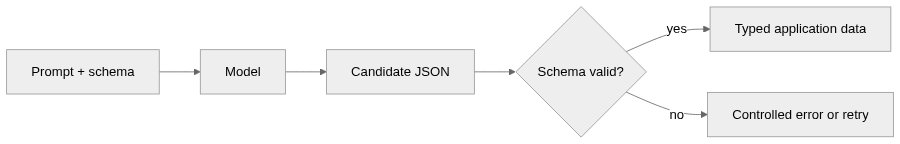

*D02 — prompt plus schema, candidate JSON, validation, typed data or a controlled error*

### Step 1 — Write the contract as a Pydantic model

Pydantic is the standard Python library for "data with rules". Field constraints such as
`ge=0, le=1` are checked automatically.

In [ ]:
from pydantic import BaseModel, Field, ValidationError

class ResearchSummary(BaseModel):
    topic: str
    summary: str
    key_points: list[str] = Field(min_length=1)        # at least one point
    tools_used: list[str] = []
    confidence: float = Field(ge=0.0, le=1.0)          # between 0 and 1

schema = ResearchSummary.model_json_schema()
print(json.dumps(schema, indent=2)[:600], "...")

### Step 2 — Make the schema *strict* and ask for it

Providers enforce a schema only in "strict" form: every object needs `additionalProperties: false`,
every property must be listed as `required`, and constraints they cannot enforce (like `minItems`)
must be removed. We keep the Pydantic model as the real contract and validate on our side regardless.

In [ ]:
def make_strict(node):
    """Recursively convert a Pydantic JSON schema into the strict form providers accept."""
    if isinstance(node, dict):
        if node.get("type") == "object":
            node["additionalProperties"] = False
            node["required"] = list(node.get("properties", {}).keys())
        for key in ("minItems", "maxItems", "minimum", "maximum", "default"):
            node.pop(key, None)
        for value in node.values():
            make_strict(value)
    elif isinstance(node, list):
        for item in node:
            make_strict(item)
    return node

RESEARCH_FORMAT = {"type": "json_schema",
                   "json_schema": {"name": "ResearchSummary", "strict": True, "schema": make_strict(ResearchSummary.model_json_schema())}}

reply = chat([{"role": "user", "content": "Summarize what a tool is in agentic AI."}], response_format=RESEARCH_FORMAT)
print("RAW REPLY:", reply["content"][:300])

### Step 3 — Validate, and explain failures in one line

`model_validate_json` parses and checks in one go. Wrap it so the program gets a typed object
or a readable one-line reason, never a crash.

In [ ]:
def validate_summary(text):
    """Return (ResearchSummary or None, reason)."""
    try:
        return ResearchSummary.model_validate_json(text), "valid"
    except ValidationError as error:
        problems = "; ".join(f"{'.'.join(map(str, e['loc']))}: {e['msg']}" for e in error.errors())
        return None, f"invalid: {problems}"
    except json.JSONDecodeError as error:
        return None, f"not JSON (was the reply cut off by max_tokens?): {error}"

summary, reason = validate_summary(reply["content"])
print("Validation :", reason)
if summary:
    print("Typed data :", summary.topic, "| confidence", summary.confidence, "| points", len(summary.key_points))

### Step 4 — Break it: plausible data that is still invalid

Models occasionally return values a human would accept and the contract does not. We fake one
such reply so the check is deterministic: `confidence` of 4.5 and an empty `key_points` list.

In [ ]:
bad_reply = json.dumps({"topic": "tools", "summary": "A tool is a capability the model may request.",
                        "key_points": [], "tools_used": [], "confidence": 4.5})
summary, reason = validate_summary(bad_reply)
print("Validation :", reason)
print("Typed data :", summary)      # None: nothing downstream can use a bad object by accident

### Checkpoint

**1. Validation passed. Does that mean the summary is factually correct?**

<details><summary>Show answer</summary>

No. Validation checks *shape* (fields, types, ranges). Factual correctness is a separate evaluation; policy (is an action allowed?) is a third check. Keep the three apart.

</details>

**2. Why keep validating in Python when the provider already enforces a strict schema?**

<details><summary>Show answer</summary>

The provider enforces only part of the contract (no `minItems`, no ranges it cannot express), some providers ignore `strict`, and a truncated reply is not JSON at all. Your code is the last line of defence.

</details>

### Recap

- **Limitation seen:** prose replies cannot be consumed by a program.
- **Layer added:** a Pydantic contract, a strict schema in the request, validation on the way in.
- **Evidence:** valid data became a typed object; `confidence=4.5` was rejected with a readable reason.

<a id="day-1-section-4"></a>

## 1.4 — Tool Calling

**Tool calling does not let the model run code.** The model receives a *description* of a
function and may reply with the tool's name and arguments. Your program validates that request,
runs the real function, and sends the result back as a `tool` message. The model never touches Python.

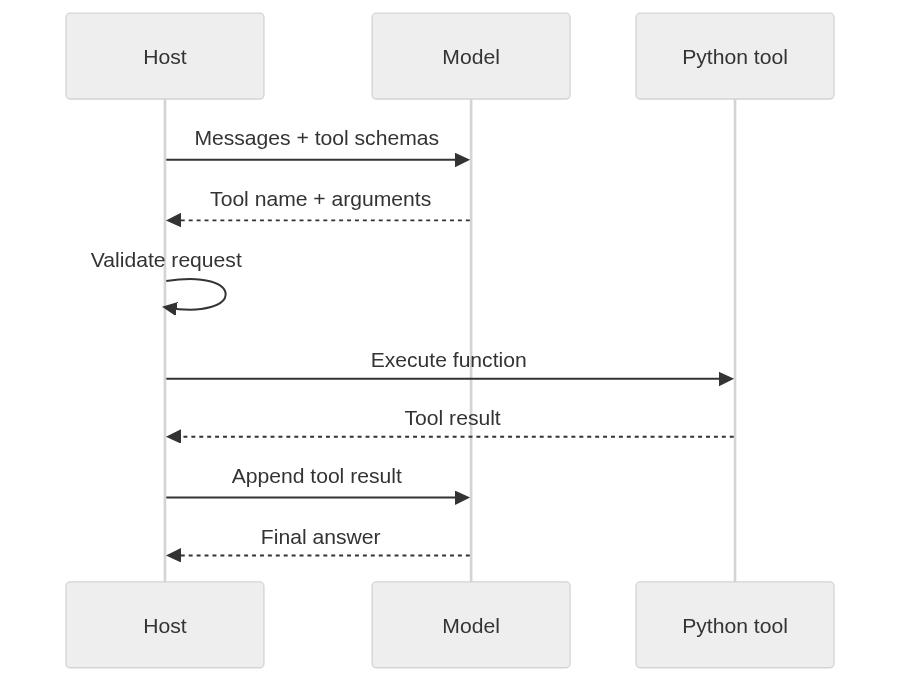

*D03 — host sends messages and tool schemas; model returns a tool request; host validates, executes, and returns the result*

### Step 1 — A calculator that is safe to expose

Never `eval()` model output. This calculator parses the expression into a syntax tree and allows
only numbers and arithmetic operators, so `__import__('os')` is rejected before anything runs.

In [ ]:
import ast, operator

_OPERATORS = {ast.Add: operator.add, ast.Sub: operator.sub, ast.Mult: operator.mul,
              ast.Div: operator.truediv, ast.Pow: operator.pow, ast.USub: operator.neg}

def _evaluate(node):
    if isinstance(node, ast.Constant) and isinstance(node.value, (int, float)):
        return node.value
    if isinstance(node, ast.BinOp) and type(node.op) in _OPERATORS:
        left, right = _evaluate(node.left), _evaluate(node.right)
        if isinstance(node.op, ast.Pow) and abs(right) > 10:
            raise ValueError("exponent limited to 10")
        return _OPERATORS[type(node.op)](left, right)
    if isinstance(node, ast.UnaryOp) and type(node.op) in _OPERATORS:
        return _OPERATORS[type(node.op)](_evaluate(node.operand))
    raise ValueError("only numbers and + - * / ** are allowed")

def calculate(expression: str) -> str:
    """Evaluate basic arithmetic WITHOUT eval()."""
    result = _evaluate(ast.parse(expression, mode="eval").body)
    return str(int(result)) if float(result).is_integer() else str(result)

print("37 * 19            ->", calculate("37 * 19"))
try:
    calculate("__import__('os').system('ls')")
except ValueError as error:
    print("malicious input     -> rejected:", error)

### Step 2 — Describe the tool to the model, and validate its arguments

A tool needs three things: a **schema** the model sees, a Pydantic **argument model** we validate
with, and the **function** we run. `make_tool` bundles them; `execute_tool_call` is the only
place a model request can turn into execution.

In [ ]:
class CalculatorArgs(BaseModel):
    expression: str = Field(min_length=1, max_length=100)

def make_tool(name, description, function, arg_model):
    """Bundle schema (what the model sees), validator, and function (what we run)."""
    return {"name": name, "function": function, "arg_model": arg_model,
            "schema": {"type": "function", "function": {
                "name": name, "description": description,
                "parameters": make_strict(arg_model.model_json_schema())}}}

def execute_tool_call(call, tools):
    """Validate a model's tool request and run it. Returns the observation as text."""
    tool = tools.get(call["name"])
    if tool is None:
        return f"Tool error: unknown tool '{call['name']}'"          # the model invented a name
    try:
        arguments = tool["arg_model"].model_validate(call["arguments"])  # 1. validate
        return tool["function"](**arguments.model_dump())               # 2. execute
    except ValidationError as error:                                    # 3a. bad arguments: say which
        first = error.errors()[0]
        return f"Tool error: argument '{'.'.join(map(str, first['loc'])) or 'input'}' {first['msg']}"
    except (ValueError, SyntaxError, ZeroDivisionError) as error:
        return f"Tool error: {str(error).splitlines()[0]}"               # 3b. report, never crash

TOOLS = {"calculator": make_tool("calculator", "Evaluate basic arithmetic. Use it instead of doing arithmetic mentally.",
                                 calculate, CalculatorArgs)}
print(json.dumps(TOOLS["calculator"]["schema"], indent=2))

### Step 3 — One complete tool turn

Watch the four hand-offs: the model *requests*, we *validate and execute*, we *append* the
observation as a `tool` message, the model *answers*.

In [ ]:
def assistant_message(reply):
    """Convert a chat() reply into the message format the API expects back in the history."""
    message = {"role": "assistant", "content": reply["content"]}
    if reply["tool_calls"]:
        message["tool_calls"] = [{"id": c["id"], "type": "function",
                                  "function": {"name": c["name"], "arguments": json.dumps(c["arguments"])}}
                                 for c in reply["tool_calls"]]
    return message

history = [{"role": "system", "content": "Use the calculator for any arithmetic."},
           {"role": "user", "content": "What is 37 * 19?"}]
tool_schemas = [t["schema"] for t in TOOLS.values()]

reply = chat(history, tools=tool_schemas)
print("1. model REQUESTS  :", reply["tool_calls"])

history.append(assistant_message(reply))
for call in reply["tool_calls"]:
    observation = execute_tool_call(call, TOOLS)                       # WE run it
    print("2. host EXECUTES   :", call["name"], call["arguments"], "->", observation)
    history.append({"role": "tool", "tool_call_id": call["id"], "content": observation})

final = chat(history, tools=tool_schemas)
print("3. model ANSWERS   :", final["content"])
print("\nMessages now:", [m["role"] for m in history])

### Step 4 — Break it: requests our code refuses

The model can invent a tool, send the wrong field, or smuggle code. None of it reaches the function.

In [ ]:
bad_requests = [
    {"id": "x1", "name": "delete_files", "arguments": {"path": "/"}},                 # invented tool
    {"id": "x2", "name": "calculator",   "arguments": {"expr": "1 + 1"}},             # wrong field name
    {"id": "x3", "name": "calculator",   "arguments": {"expression": "__import__('os')"}},  # code smuggling
    {"id": "x4", "name": "calculator",   "arguments": {"expression": "2 ** 999"}},    # resource abuse
]
for call in bad_requests:
    print(f"{call['name']:<14} {str(call['arguments']):<40} -> {execute_tool_call(call, TOOLS)}")

### Checkpoint

**1. Which line of code actually multiplied 37 by 19?**

<details><summary>Show answer</summary>

`tool['function'](**arguments.model_dump())` inside `execute_tool_call`, called by *our* loop. The model only produced the request `{'expression': '37*19'}`.

</details>

**2. Why validate arguments with a Pydantic model when the provider already saw a strict schema?**

<details><summary>Show answer</summary>

The schema is advice to the model; the model can still produce anything, and some providers do not enforce it. Validation in our code is what stands between a bad request and a real function call.

</details>

### Recap

- **Limitation seen:** the model cannot act, and its requests cannot be trusted blindly.
- **Layer added:** tool schema + argument validation + host-side execution + `tool` message.
- **Evidence:** four malformed requests were refused before any function ran.

<a id="day-1-section-5"></a>

## 1.5 — The Agent Loop — You Build It

After one tool result the model may ask for another tool, or answer. That is a **loop**, and
the loop is what makes a program *agentic*. Your code must own two things the model cannot:
**termination** (a step limit) and **safety** (validate every request). This is the day's one
hands-on exercise: write the loop yourself, check it, then compare with the reference.

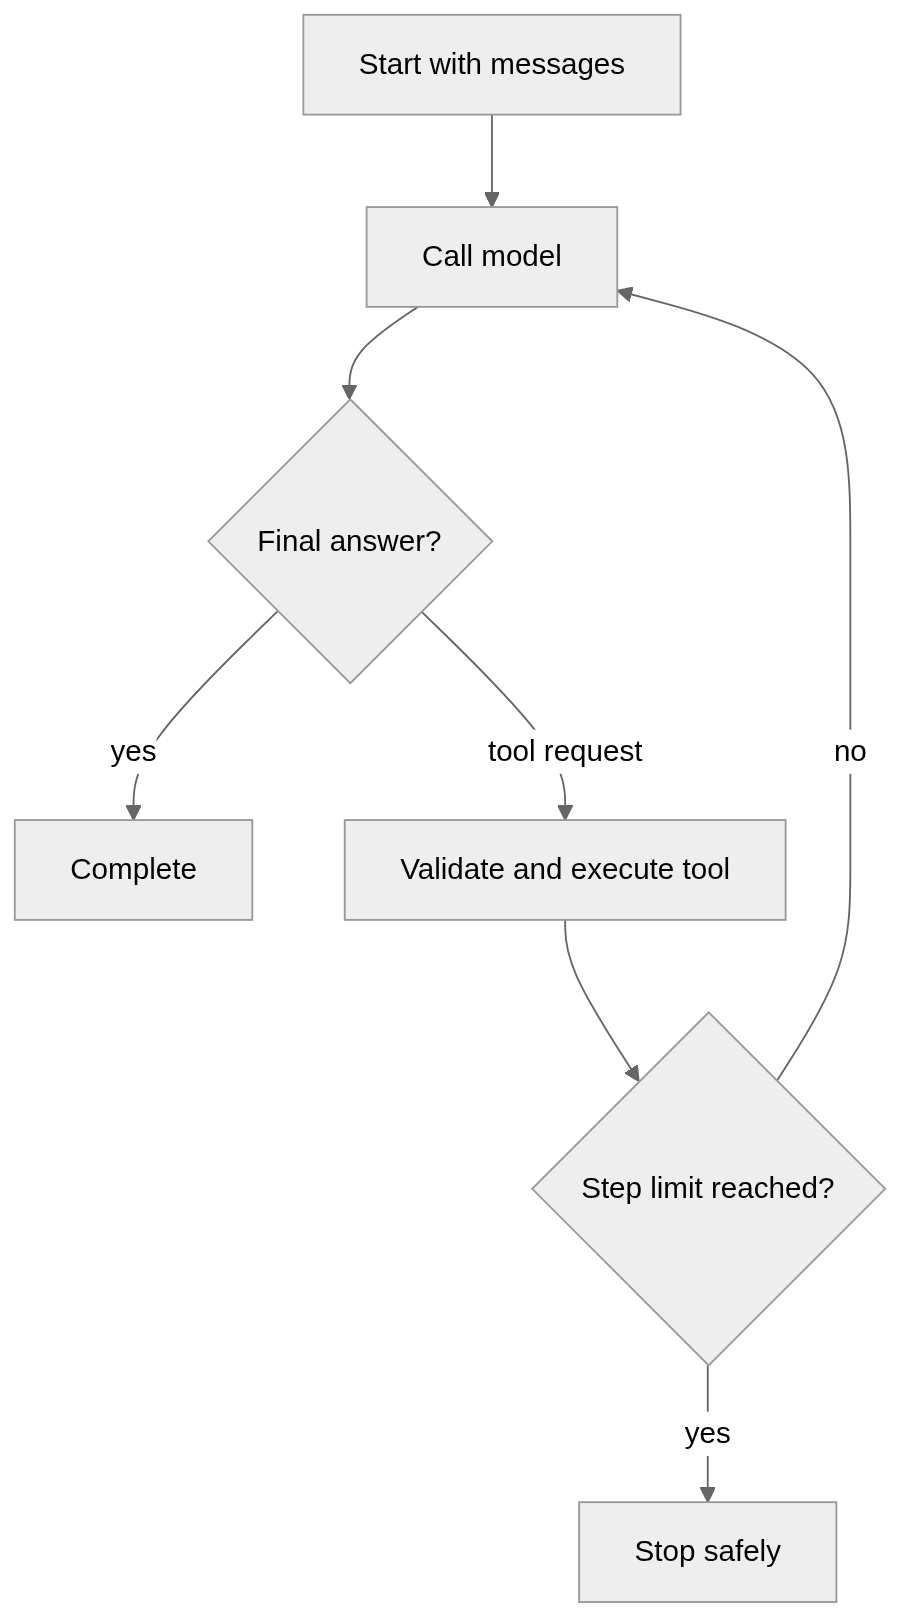

*D04 — call the model; if final answer stop; else validate and execute the tool; stop safely at the step limit*

### Why the program owns termination

"Stop when you are done" in a prompt is not a limit. A confused model can repeat a request
forever, and each turn costs tokens and money. Small errors also compound: if each decision is
95% right, ten independent decisions are all right only about 60% of the time
(`0.95 ** 10 ≈ 0.60`). Bounded loops, validation, and fewer calls are the remedy.

### The contract

```python
run_agent(question, tools, model=chat, max_steps=5, system=SYSTEM_PROMPT, response_format=None)
```
returns a dict with `status` (`"completed"`, `"max_steps"` or `"failed"`), `answer`, `messages`,
`steps`, `tools_used`, `usage`, `error`. Rules: append every tool result; stop on a final answer;
return `"failed"` for an unknown tool or a repeated identical request; return `"max_steps"` when
the limit is reached. Everything you need already exists: `chat`, `assistant_message`, `execute_tool_call`.

In [ ]:
SYSTEM_PROMPT = "You are a careful research assistant. Use tools when they help. Answer only when you have what you need."

def run_agent(question, tools, model=chat, max_steps=5, system=SYSTEM_PROMPT, response_format=None):
    """YOUR TURN. Return {"status", "answer", "messages", "steps", "tools_used", "usage", "error"}."""
    messages = [{"role": "system", "content": system}, {"role": "user", "content": question}]
    tool_schemas = [t["schema"] for t in tools.values()]
    # TODO: for step in 1..max_steps:
    # TODO:     reply = model(messages, tools=tool_schemas, response_format=response_format)
    # TODO:     append assistant_message(reply)
    # TODO:     if no tool_calls -> return status "completed" with reply["content"]
    # TODO:     for each call: reject unknown tools and repeated identical requests (status "failed"),
    # TODO:                    otherwise execute_tool_call and append a "tool" message
    # TODO: after the loop -> status "max_steps"
    raise NotImplementedError("write the loop")

print("run_agent stub defined - fill in the TODOs, then run the check below")

### Behavioural check

A scripted fake model stands in for `chat`, so the check is exact and free. It prints a hint
instead of failing while your function is unfinished.

In [ ]:
def make_fake_model(script):
    """A stand-in model that returns the scripted replies in order (same interface as chat)."""
    replies = iter(script)
    def fake(messages, tools=None, response_format=None):
        return next(replies)
    return fake

class AddArgs(BaseModel):
    a: float
    b: float

def run_loop_checks():
    calls = []
    def add(a, b):
        calls.append((a, b)); return str(a + b)
    add_tool = {"add": make_tool("add", "Add two numbers.", add, AddArgs)}

    # Case 1: one tool request, then a final answer.
    script = [_mock_reply(calls=[{"id": "c1", "name": "add", "arguments": {"a": 2, "b": 3}}]),
              _mock_reply("The result is 5.")]
    result = run_agent("Add 2 and 3", add_tool, model=make_fake_model(script))
    assert result["status"] == "completed" and result["answer"] == "The result is 5.", result
    assert calls == [(2, 3)], "the tool must run exactly once with the model's arguments"
    assert any(m["role"] == "tool" for m in result["messages"]), "the tool result must be appended"

    # Case 2: an unknown tool must be rejected before anything runs.
    script = [_mock_reply(calls=[{"id": "c2", "name": "delete_everything", "arguments": {}}])]
    assert run_agent("x", add_tool, model=make_fake_model(script))["status"] == "failed"

    # Case 3: a model that never answers must hit the step limit.
    forever = lambda messages, tools=None, response_format=None: _mock_reply(
        calls=[{"id": f"c{len(messages)}", "name": "add", "arguments": {"a": len(messages), "b": 1}}])
    assert run_agent("x", add_tool, model=forever, max_steps=3)["status"] == "max_steps"
    print("PASS: dispatch, unknown-tool rejection, and the step limit all behave correctly")

try:
    run_loop_checks()
except NotImplementedError:
    print("Not implemented yet. Fill in run_agent above, or read the reference solution below and re-run this cell.")

### Reference solution

Read it line by line even if your check passed, then re-run the check cell. **This version is
the loop used for the rest of the day.**

In [ ]:
# --- Reference solution ------------------------------------------------------------
def run_agent(question, tools, model=chat, max_steps=5, system=SYSTEM_PROMPT, response_format=None):
    messages = [{"role": "system", "content": system}, {"role": "user", "content": question}]
    tool_schemas = [t["schema"] for t in tools.values()]
    usage = {"prompt_tokens": 0, "completion_tokens": 0, "total_tokens": 0}
    seen_requests, tools_used = set(), []

    def finish(status, answer="", error=None, steps=0):
        return {"status": status, "answer": answer, "messages": messages, "steps": steps,
                "tools_used": tools_used, "usage": usage, "error": error}

    for step in range(1, max_steps + 1):                      # bounded: never loops forever
        reply = model(messages, tools=tool_schemas, response_format=response_format)
        for key in usage:
            usage[key] += reply["usage"].get(key, 0)
        messages.append(assistant_message(reply))             # the model's turn goes into history
        if not reply["tool_calls"]:                           # no request = final answer
            return finish("completed", answer=reply["content"], steps=step)
        for call in reply["tool_calls"]:
            if call["name"] not in tools:                     # validate BEFORE executing anything
                return finish("failed", error=f"unknown tool '{call['name']}'", steps=step)
            signature = (call["name"], json.dumps(call["arguments"], sort_keys=True))
            if signature in seen_requests:                    # same request twice = stuck model
                return finish("failed", error=f"repeated request: {call['name']}{call['arguments']}", steps=step)
            seen_requests.add(signature)
            observation = execute_tool_call(call, tools)      # the HOST runs the function
            tools_used.append(call["name"])
            messages.append({"role": "tool", "tool_call_id": call["id"], "content": observation})
            print(f"  step {step}: {call['name']}({call['arguments']}) -> {observation[:70]}")
    return finish("max_steps", error=f"stopped after {max_steps} steps without an answer", steps=max_steps)

run_loop_checks()

### Now with the real model and two tools

The notes tool is a tiny course-note collection (Day 2 replaces it with real retrieval).
Watch the trace: the agent decides the order of the tools; our loop decides everything else.

In [ ]:
COURSE_NOTES = {
    "python": "Python is a high-level language known for readable syntax; its ecosystem makes it common in AI engineering.",
    "agent": "In this course an agent is an application that uses a model to choose actions, executes tools through host code, observes results, and decides when to stop.",
    "tool": "A tool is a schema-described capability. The model requests it; the host validates the arguments and executes the function.",
    "structured output": "Structured output gives model replies a predictable shape that application code can validate and consume.",
}

class SearchArgs(BaseModel):
    query: str = Field(min_length=2, max_length=200)

def search_local_notes(query: str) -> str:
    """Return the course notes whose key appears in the query (a stand-in for real retrieval)."""
    hits = [text for key, text in COURSE_NOTES.items() if key in query.lower()]
    return "\n".join(hits) if hits else "No matching note was found."

TOOLS["search_local_notes"] = make_tool("search_local_notes", "Search the small local course-note collection for background facts.",
                                        search_local_notes, SearchArgs)

result = run_agent("What is an agent, and what is 12 * 9?", TOOLS)
print("\nstatus     :", result["status"], "| steps:", result["steps"], "| tools used:", result["tools_used"])
print("answer     :", result["answer"][:300])
print("usage      :", result["usage"])

### Break it: force the limit, and catch a stuck model

`max_steps=1` stops an honest run early and *says so*. A model that repeats the same request
is stopped by the duplicate check instead of burning all its steps.

In [ ]:
limited = run_agent("What is an agent, and what is 12 * 9?", TOOLS, max_steps=1)
print("max_steps=1  ->", limited["status"], "|", limited["error"])

stuck = lambda messages, tools=None, response_format=None: _mock_reply(
    calls=[{"id": "same", "name": "calculator", "arguments": {"expression": "1+1"}}])
repeated = run_agent("What is 1 + 1?", TOOLS, model=stuck)
print("stuck model  ->", repeated["status"], "|", repeated["error"], "| steps used:", repeated["steps"], "of 5")

### Checkpoint

**1. Why must the application, rather than the model, own execution and termination?**

<details><summary>Show answer</summary>

The model only emits text that *looks like* a request. Only the host can check the tool exists, validate arguments, run it, and count steps. If the model owned termination, a confused prompt could loop forever or call anything.

</details>

**2. Reaching `max_steps` returned a status instead of raising an exception. Why is that better?**

<details><summary>Show answer</summary>

The partial trace is still useful evidence, and the caller can decide what to do. Reporting incomplete work honestly beats pretending the run completed or crashing the program.

</details>

### Recap

- **Limitation seen:** one tool turn is not enough; the number of turns is unknown in advance.
- **Layer added:** a bounded loop with validation, duplicate detection, and an honest status.
- **Evidence:** the checks passed; the limit and the stuck model were both stopped with a reason.

<a id="day-1-section-6"></a>

## 1.6 — The Same Loop in LangGraph (Optional)

LangGraph represents a loop you already understand as explicit **state**, **nodes**, and
**edges**. It earns its place when a workflow needs branching, checkpoints, or resumability
(Day 3 and Day 5). It is not the agent's intelligence; it organises the loop.

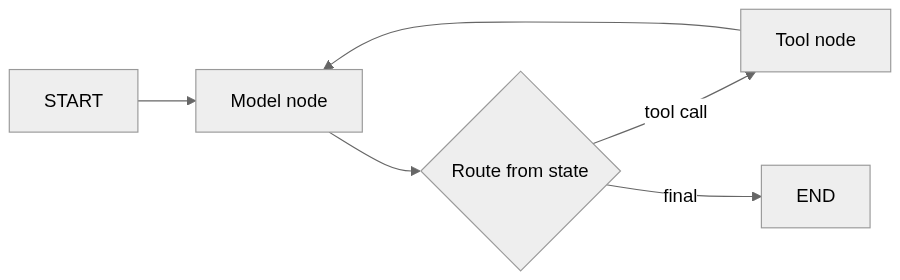

*D05 — model node routes to the tool node on a tool call, back to the model, or to END*

### When is an agent the right design?

Use plain code when the steps are known. Use a hybrid workflow when one bounded judgement
benefits from a model. Use an agent only when the next action cannot be predetermined, the
action set is small, failures are containable, and success can be measured. If those answers are weak, build a workflow.

In [ ]:
%pip install -q langgraph

In [ ]:
try:
    from langgraph.graph import END, START, StateGraph
    from typing import TypedDict
    GRAPH_AVAILABLE = True
except ImportError:
    GRAPH_AVAILABLE = False
    print("LangGraph is not installed; re-run the pip cell above. Skipping this section is fine.")

if GRAPH_AVAILABLE:
    class AgentState(TypedDict):
        messages: list          # the same history our loop kept
        steps: int
        max_steps: int
        status: str

    tool_schemas = [t["schema"] for t in TOOLS.values()]

    def model_node(state):                                     # = "call the model"
        reply = chat(state["messages"], tools=tool_schemas)
        messages = state["messages"] + [assistant_message(reply)]
        return {"messages": messages, "steps": state["steps"] + 1,
                "status": "completed" if not reply["tool_calls"] else "working"}

    def tool_node(state):                                      # = "validate and execute"
        last = state["messages"][-1]
        results = [{"role": "tool", "tool_call_id": c["id"],
                    "content": execute_tool_call({"id": c["id"], "name": c["function"]["name"],
                                                  "arguments": json.loads(c["function"]["arguments"])}, TOOLS)}
                   for c in last["tool_calls"]]
        return {"messages": state["messages"] + results}

    def route(state):                                          # = the if/else in our loop
        if state["status"] == "completed":
            return END
        return "tools" if state["steps"] < state["max_steps"] else END

    builder = StateGraph(AgentState)
    builder.add_node("model", model_node)
    builder.add_node("tools", tool_node)
    builder.add_edge(START, "model")
    builder.add_conditional_edges("model", route, {"tools": "tools", END: END})
    builder.add_edge("tools", "model")
    graph = builder.compile()

    final_state = graph.invoke({"messages": [{"role": "system", "content": SYSTEM_PROMPT},
                                             {"role": "user", "content": "What is 12 * 9?"}],
                                "steps": 0, "max_steps": 5, "status": "working"})
    print("status :", final_state["status"], "| steps:", final_state["steps"])
    print("answer :", final_state["messages"][-1]["content"][:200])
    print("roles  :", [m["role"] for m in final_state["messages"]])

### Checkpoint

**1. Map each part of LangGraph to a line in your `run_agent`.**

<details><summary>Show answer</summary>

`model_node` = the `model(...)` call plus appending the assistant message; `tool_node` = the `execute_tool_call` loop; `route` = the `if not reply['tool_calls']` and the step-limit check; the graph's edges = the `for` loop returning to the model.

</details>

**2. What did LangGraph *not* provide?**

<details><summary>Show answer</summary>

Tools, argument validation, the step limit's value, evaluation, and policy. Those stay yours. The framework only organises the control flow.

</details>

### Recap

- **Limitation seen:** a hand-written loop is hard to extend with branching, pausing, or resuming.
- **Layer added:** the same loop as explicit state, nodes, and conditional edges.
- **Evidence:** the graph reached the same answer through the same message roles.

<a id="day-1-section-7"></a>

## 1.7 — Project — Smart Research Assistant

Everything is on the table: `chat`, a validated contract (`ResearchSummary`), two safe tools,
and the bounded loop. The project wires them together and then judges the assistant by its
**evidence and trace**, not by how fluent the final paragraph sounds.

### Step 1 — Assemble it

The assistant is `run_agent` with a strict final format. The answer is parsed into
`ResearchSummary`, so downstream code receives typed data or a clear failure.

In [ ]:
ASSISTANT_PROMPT = (SYSTEM_PROMPT + " Use the calculator for arithmetic and search_local_notes for course concepts. "
                    "When you have the evidence, answer with the requested JSON only.")

def research(question, model=chat, max_steps=5):
    """Run the assistant and return a typed result plus its trace."""
    run = run_agent(question, TOOLS, model=model, max_steps=max_steps, system=ASSISTANT_PROMPT,
                    response_format=RESEARCH_FORMAT)
    summary, reason = (validate_summary(run["answer"]) if run["status"] == "completed" else (None, run["error"]))
    return {"question": question, "status": run["status"] if summary else "failed",
            "summary": summary, "reason": reason, "tools_used": run["tools_used"],
            "steps": run["steps"], "usage": run["usage"], "messages": run["messages"]}

outcome = research("What is structured output, and what is 144 / 12?")
print("\nstatus     :", outcome["status"], "|", outcome["reason"])
print("tools used :", outcome["tools_used"], "| steps:", outcome["steps"], "| tokens:", outcome["usage"]["total_tokens"])
if outcome["summary"]:
    print("summary    :", outcome["summary"].summary[:200])
    print("confidence :", outcome["summary"].confidence)

### Step 2 — A behaviour suite

Three questions with known expectations: which tools *should* be used, did the run finish, and
was the final answer valid. This is a tiny evaluation; Day 2 grows it into a golden set.

In [ ]:
SUITE = [
    ("What is 37 * 19?",                         {"calculator"}),
    ("What is an agent?",                        {"search_local_notes"}),
    ("What is a tool, and what is 12 * 9?",      {"calculator", "search_local_notes"}),
]

print(f"{'question':<42} {'status':<10} {'tools':<34} valid")
for question, expected_tools in SUITE:
    outcome = research(question)
    tools_ok = expected_tools.issubset(set(outcome["tools_used"]))
    valid = outcome["summary"] is not None
    verdict = "PASS" if (outcome["status"] == "completed" and tools_ok and valid) else "CHECK"
    print(f"{question:<42} {outcome['status']:<10} {str(sorted(set(outcome['tools_used']))):<34} {valid}  {verdict}")

### Step 3 — Three failures, each caught by a different layer

Do not call every failure a "hallucination". Locate the layer that failed: the tool layer, the
loop, or the output contract. Each one below is stopped by the code you wrote today.

In [ ]:
# Failure 1: an invalid tool argument (tool layer). We call the executor directly.
print("1. tool layer   :", execute_tool_call({"id": "f1", "name": "calculator", "arguments": {"expression": "10 / 0"}}, TOOLS))

# Failure 2: a model that repeats itself (loop layer).
repeated = research("What is 1 + 1?", model=stuck)
print("2. loop layer   :", repeated["status"], "|", repeated["reason"])

# Failure 3: a final answer that breaks the contract (output layer).
broken_final = make_fake_model([_mock_reply(json.dumps({"topic": "x", "summary": "y", "key_points": [], "confidence": 2}))])
invalid = research("Anything", model=broken_final)
print("3. output layer :", invalid["status"], "|", invalid["reason"])

### Try it yourself

Add a third tool: `word_count(text)` that returns the number of words. Register it with
`make_tool` and ask the assistant "How many words are in 'agents use tools through code'?".
Predict which tool it should use before running.

In [ ]:
# --- Worked solution ---------------------------------------------------------------
class WordCountArgs(BaseModel):
    text: str = Field(min_length=1, max_length=500)

def word_count(text: str) -> str:
    return str(len(text.split()))                       # the whole tool: split on whitespace, count

TOOLS["word_count"] = make_tool("word_count", "Count the words in a piece of text.", word_count, WordCountArgs)

# The mock model does not know this tool, so we script the request to test OUR side of the contract;
# in LIVE mode the real model chooses the tool itself.
scripted = make_fake_model([
    _mock_reply(calls=[{"id": "w1", "name": "word_count", "arguments": {"text": "agents use tools through code"}}]),
    _mock_reply(json.dumps({"topic": "word count", "summary": "The sentence has 5 words.", "key_points": ["5 words"],
                            "tools_used": ["word_count"], "confidence": 0.95})),
])
outcome = research("How many words are in 'agents use tools through code'?", model=chat if LIVE else scripted)
print("\nstatus:", outcome["status"], "| tools used:", outcome["tools_used"], "| answer:", outcome["summary"].summary if outcome["summary"] else outcome["reason"])

### Checkpoint

**1. The assistant produced a fluent paragraph with `confidence: 0.9`. What would you check before trusting it?**

<details><summary>Show answer</summary>

The trace: which tools ran, with what arguments, and what they returned. Then whether the summary is consistent with those observations. Fluency and a confidence number are model output, not evidence.

</details>

**2. Which parts of today's assistant are *application-specific* and which would you reuse on Day 5?**

<details><summary>Show answer</summary>

Reusable: `chat`, `make_tool`/`execute_tool_call`, the bounded loop, validation helpers. Application-specific: the prompt, the two tools, the `ResearchSummary` contract, and the suite. Day 5 turns the reusable parts into a harness.

</details>

### Recap

- **Limitation seen:** a fluent answer says nothing about whether the process was sound.
- **Layer added:** a typed final contract, a behaviour suite, and failure cases mapped to layers.
- **Evidence:** the suite table, and three failures each stopped with a named reason.

## Day 1 completion checklist

- [ ] I can point to the line that sends a request, the data that describes a tool, the function that executes it, and the condition that stops the loop.
- [ ] I ran everything in mock mode and (if I had a key) compared at least one live reply.
- [ ] I attempted `run_agent` before reading the reference solution and can explain it line by line.
- [ ] I can name the layer that failed for each of the three failures in the project.

**Tomorrow:** the loop stays the same; Day 2 replaces the tiny course notes with real retrieval and asks how to prove an answer used its evidence.